# Pretrained models

In [1]:
import json
import time
from io import BytesIO
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

PyTorch includes a number of pre-trained models in the `torchvision.models` module. These models are trained on the ImageNet dataset, which contains 1.4 million images and 1000 classes.

To initialize a pre-trained model, you need to first load the weights for the model, and then pass those weights to the model when you initialize it. For example, to load a pre-trained VGG16 model, you can do the following:

In [3]:
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

weights = VGG16_Weights.DEFAULT
model = vgg16(weights=weights)

model.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\carlo/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:31<00:00, 17.3MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

For more information on the available pre-trained models, see the [torchvision documentation](https://docs.pytorch.org/vision/0.26/models.html).

The pre-trained models in `torchvision` come with a set of pre-processing transforms that are designed to prepare the input images in the same way as the images that were used to train the model. You can access these transforms using the `transforms` method of the weights object. For example, to get the pre-processing transforms for the VGG16 model, you can do the following:

In [4]:
pre_trans = weights.transforms()
pre_trans

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

To help test our model, we can use random images from the [Picsum Photos](https://picsum.photos/) service, which provides random images of a specified size. 

In [5]:
def fetch_picsum_image(**kwargs) -> Image.Image:
    """
    Fetch an image from https://picsum.photos and return it as a PIL image.

    Kwargs:
        width (int): image width, default 200
        height (int): image height, default 300
        id (int | str): alias for image_id
        timeout (float | int): request timeout in seconds, default 10

    Returns:
        PIL.Image.Image
    """
    width = int(kwargs.get("width", 200))
    height = int(kwargs.get("height", 300))
    image_id = kwargs.get("id", None)
    timeout = float(kwargs.get("timeout", 10))

    if width <= 0 or height <= 0:
        raise ValueError("width and height must be positive integers")

    if image_id is not None:
        url = f"https://picsum.photos/id/{image_id}/{width}/{height}"
    else:
        # Random image endpoint; query param helps avoid cached repeats.
        url = f"https://picsum.photos/{width}/{height}?_={int(time.time() * 1000)}"

    req = Request(url, headers={"User-Agent": "python-picsum-client/1.0"})
    with urlopen(req, timeout=timeout) as resp:
        data = resp.read()

    return Image.open(BytesIO(data)).convert("RGB")

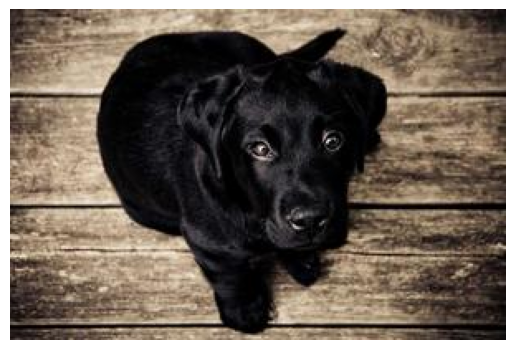

In [6]:
image = fetch_picsum_image(width=300, height=200, id=237)

plt.imshow(image)
plt.axis('off')
plt.show()

Before making predictions, let's pre-process the image using the pre-processing transforms that we got from the weights object.

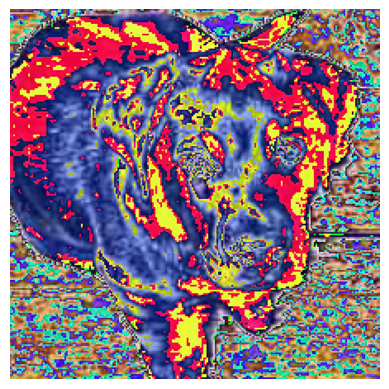

In [7]:
image_processed = pre_trans(image)

plt.imshow(F.to_pil_image(torch.squeeze(image_processed)))
plt.axis('off')
plt.show()

While it looks weird, this pre-processing actually helps the model make better predictions. The actual transformations applied by the pre-processing transforms are as follows:
- Resize the image to 256 pixels on the shorter side, while maintaining the aspect ratio.
- Center crop the image to 224x224 pixels. This is what changes the aspect ratio of the image, as well as zooming in to the center of the image.
- Normalize the pixel values using the mean and standard deviation of the ImageNet dataset. This is what causes the weird colors.

Using this pre-processing pipeline means that we can simply feed any arbitrary image into the model and it will work regardless of the original size or aspect ratio of the image.

In [10]:
imagenet_classes = json.load(open('../data/pretrained_model_jsons/imagenet_class_index.json'))

def classify(_model, _preprocessing, _image, top_k=5):
    img_input = _preprocessing(_image).to(device)
    output = _model(img_input.unsqueeze(0))

    predictions = torch.topk(output[0], top_k)
    probs = nn.functional.softmax(output, dim=1)[0]

    res = [(idx, probs[idx]) for idx in predictions.indices.tolist()]

    return res

def index_to_label(index):
    return imagenet_classes[str(index)][1]

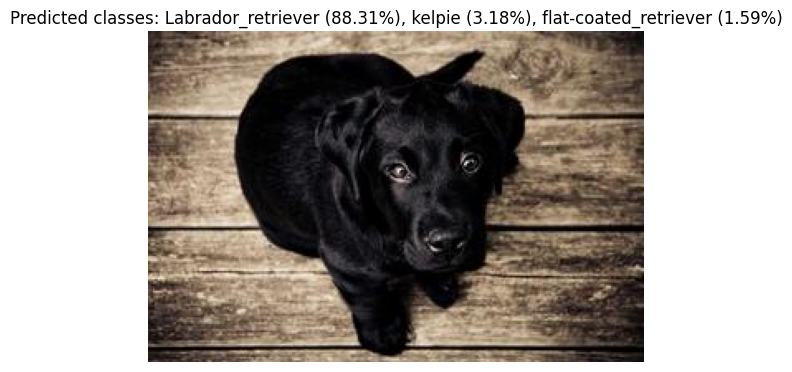

In [11]:
pred = classify(model, pre_trans, image, top_k=3)
plt.figure()
plt.axis('off')
plt.imshow(image)
_p = [f"{index_to_label(idx)} ({prob:.2%})" for idx, prob in pred]
plt.title(f"Predicted classes: {', '.join(_p)}")
plt.show()

We can also classify a batch of images at once, which is more efficient than classifying each image individually. To do this, we can stack the pre-processed images into a single tensor and pass that tensor through the model. The model will then return a batch of predictions, which we can process in the same way as we did for a single image.

In [12]:
def classify_batch(_model, _preprocessing, _images, top_k=5):
    img_inputs = torch.stack([_preprocessing(img) for img in _images]).to(device)
    outputs = _model(img_inputs)

    batch_predictions = torch.topk(outputs, top_k)

    batch_probs = nn.functional.softmax(outputs, dim=1)

    batch_res = []
    for i in range(len(_images)):
        res = [(idx, batch_probs[i][idx]) for idx in batch_predictions.indices[i].tolist()]
        batch_res.append(res)

    return batch_res

In [13]:
def download_random_images(n=5, width=300, height=200):
    images = []
    for _ in tqdm(range(n)):
        img = fetch_picsum_image(width=width,height=height)
        images.append(img)

    return images

In [15]:
batch = download_random_images(n=5, width=400, height=400)

100%|██████████| 5/5 [00:01<00:00,  3.53it/s]


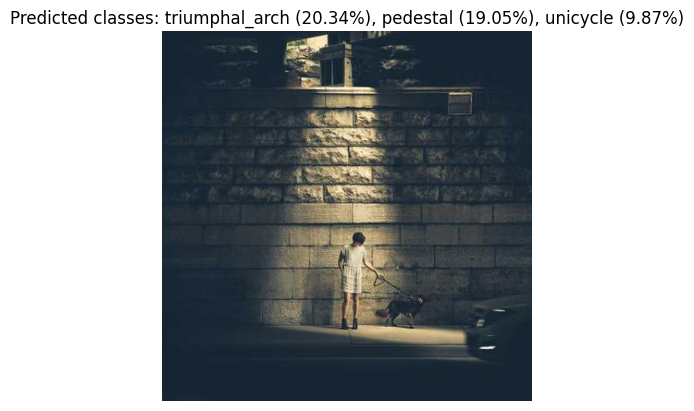

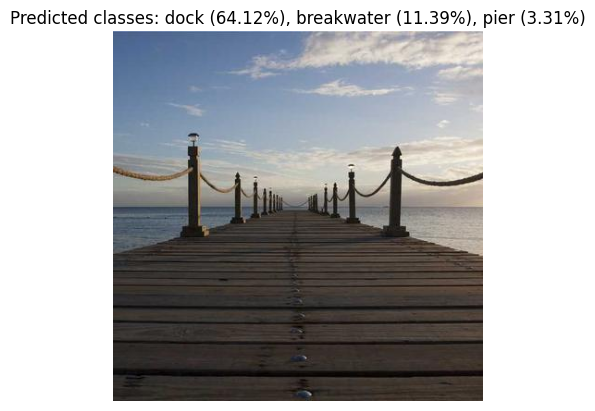

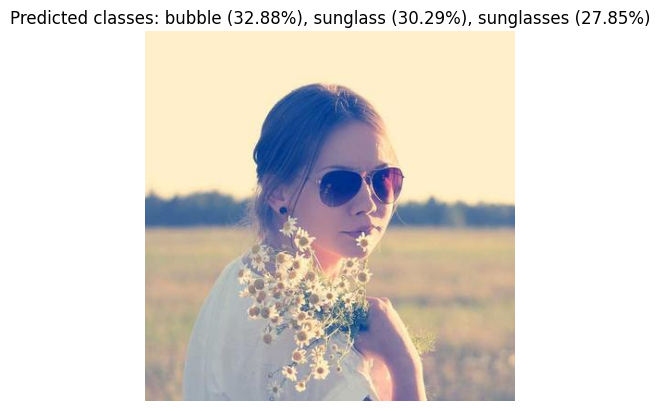

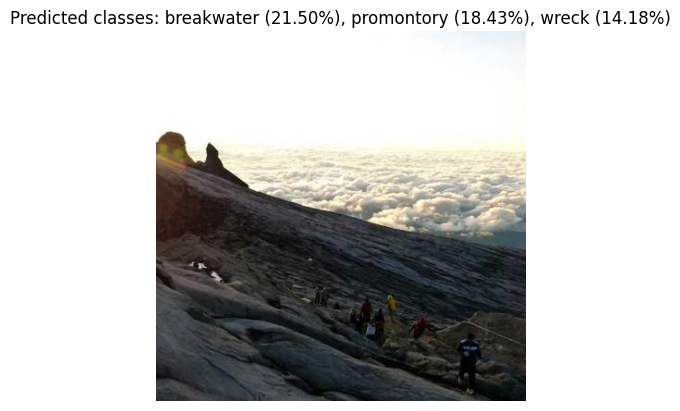

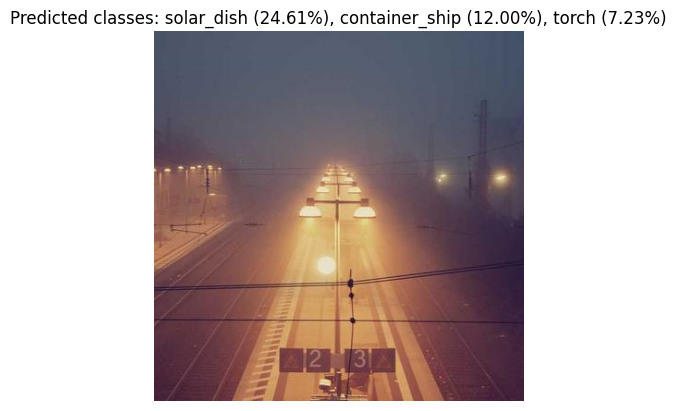

In [16]:
batch_preds = classify_batch(model, pre_trans, batch, top_k=3)

for i, preds in enumerate(batch_preds):
    plt.figure()
    plt.axis('off')
    plt.imshow(batch[i])
    idx, prob = preds[0]
    title = f"{index_to_label(idx)} ({prob:.2%})"
    _p = [f"{index_to_label(idx)} ({prob:.2%})" for idx, prob in preds]
    plt.title(f"Predicted classes: {', '.join(_p)}")

## Learning Exercise

### 1. Select some (at least 3) images from your photo library and classify them using this model.

If you don't have any image, feel free to search for images online. Just make sure to select the ones you want to try out instead of using random images.

### 2. Based on the results from images used in this notebook and the ones you provided, what are some strengths and weaknesses of the VGG16 pre-trained model?

### 3. Find another pre-trained model and repeat this exercise using it instead of the VGG16 one. Does it perform better or worse?

### 4. Write your final conclussions